In [30]:
import pandas as pd
import numpy as np 
import seaborn as sns
import matplotlib.pyplot as plt
import ipaddress

In [31]:
# Reading The Datasets
fruad_data=pd.read_csv('../data/raw/Fraud_Data.csv')
credit_Card_data=pd.read_csv('../data/raw/creditcard.csv')
IpAddress__data=pd.read_csv('../data/raw/IpAddress_to_Country.csv')




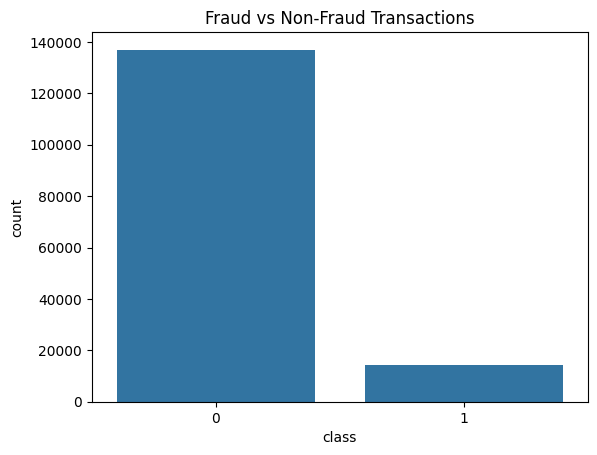

In [32]:


# Target class distribution
sns.countplot(x='class', data=fruad_data)
plt.title("Fraud vs Non-Fraud Transactions")
plt.show()

This graph Shows That, almost the amount of fruad is the range between 10,000 to 20,00

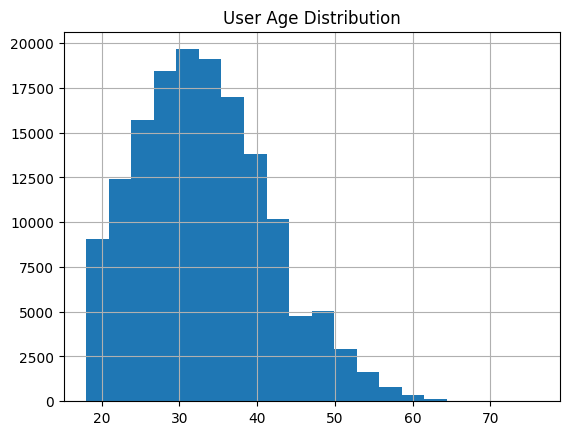

In [33]:
# Age distribution
fruad_data['age'].hist(bins=20)
plt.title("User Age Distribution")
plt.show()


From the data set Age distribution the range between 25 to 35 age are participant in the data set

### Bivarient Analysis

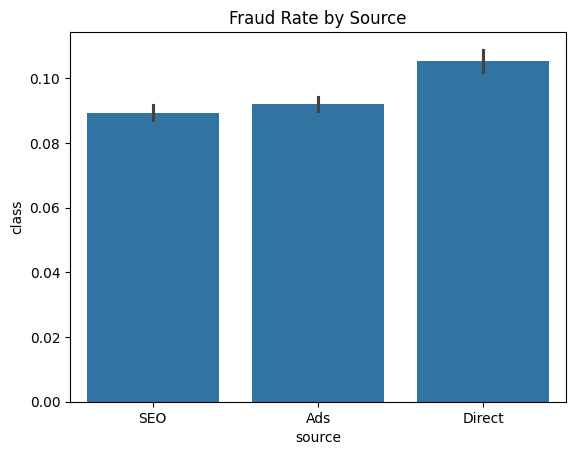

In [34]:
# Fraud rate by source
sns.barplot(x='source', y='class', data=fruad_data)
plt.title("Fraud Rate by Source")
plt.show()




The direct source of fruad is high than the rest two

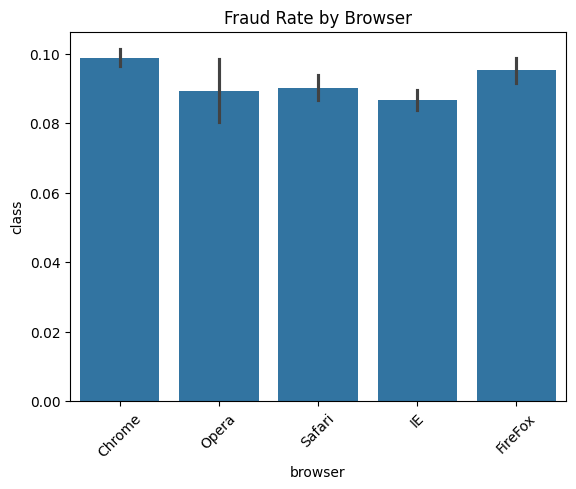

In [35]:
# Fraud rate by browser
sns.barplot(x='browser', y='class', data=fruad_data)
plt.title("Fraud Rate by Browser")
plt.xticks(rotation=45)
plt.show()

According to the Graph most users who face the fruad is chrom browser users

In [36]:
print(fruad_data['ip_address'].head(10))


0    7.327584e+08
1    3.503114e+08
2    2.621474e+09
3    3.840542e+09
4    4.155831e+08
5    2.809315e+09
6    3.987484e+09
7    1.692459e+09
8    3.719094e+09
9    3.416747e+08
Name: ip_address, dtype: float64


### Merge Dataset

In [37]:
# Convert IP string to integer


# Convert float to int first, then to IP address string
fruad_data['ip_int'] = fruad_data['ip_address'].astype(int)
fruad_data['ip_address'] = fruad_data['ip_int'].apply(lambda x: str(ipaddress.IPv4Address(x)))


IpAddress__data['lower'] = IpAddress__data['lower_bound_ip_address'].apply(
    lambda x: str(ipaddress.IPv4Address(int(x)))
)
IpAddress__data['upper'] = IpAddress__data['upper_bound_ip_address'].apply(
    lambda x: str(ipaddress.IPv4Address(int(x)))
)


In [48]:
IpAddress__data['upper'] 

0               1.0.0.255
1               1.0.1.255
2               1.0.3.255
3               1.0.7.255
4              1.0.15.255
               ...       
138841    223.255.243.255
138842    223.255.247.255
138843    223.255.253.255
138844    223.255.254.255
138845    223.255.255.255
Name: upper, Length: 138846, dtype: object

In [43]:
fruad_data.columns

Index(['user_id', 'signup_time', 'purchase_time', 'purchase_value',
       'device_id', 'source', 'browser', 'sex', 'age', 'ip_address', 'class',
       'ip_int'],
      dtype='object')

In [49]:
fruad_data['ip_address']

0             43.173.1.96
1           20.225.83.219
2           156.64.132.28
3           228.234.6.235
4           24.197.75.141
               ...       
151107     205.180.112.94
151108      145.96.232.53
151109     163.210.84.251
151110    214.165.144.180
151111    244.155.100.126
Name: ip_address, Length: 151112, dtype: object

In [ ]:
# Merge fraud_data with country using IP range lookup
def find_country(ip):
    matched = IpAddress__data[(IpAddress__data['lower'] <= ip) & (IpAddress__data['upper'] >= ip)]
    return matched['country'].values[0] if not matched.empty else 'Unknown'

fruad_data['ip_address']= fruad_data['ip_address'].apply(find_country)


In [41]:
# Time-based features
fruad_data['hour_of_day'] = fruad_data['purchase_time'].dt.hour
fruad_data['day_of_week'] = fruad_data['purchase_time'].dt.dayofweek
fruad_data['time_since_signup'] = (fruad_data['purchase_time'] - fruad_data['signup_time']).dt.total_seconds() / 3600  # in hours


AttributeError: Can only use .dt accessor with datetimelike values

In [ ]:
from imblearn.over_sampling import SMOTE
from sklearn.model_selection import train_test_split

# Select features and target
X = fruad_data.drop(['class', 'ip_address', 'signup_time', 'purchase_time'], axis=1)
y = fruad_data['class']

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(X, y, stratify=y, test_size=0.2, random_state=42)

# Apply SMOTE only on training data
smote = SMOTE(random_state=42)
X_train_resampled, y_train_resampled = smote.fit_resample(X_train, y_train)


In [ ]:
from sklearn.preprocessing import StandardScaler
from sklearn.preprocessing import OneHotEncoder
from sklearn.compose import ColumnTransformer

# Identify numerical and categorical features
num_cols = ['purchase_value', 'age', 'time_since_signup']
cat_cols = ['source', 'browser', 'sex', 'country']

# Preprocessing pipeline
preprocessor = ColumnTransformer([
    ('num', StandardScaler(), num_cols),
    ('cat', OneHotEncoder(handle_unknown='ignore'), cat_cols)
])

# Fit on training
X_train_preprocessed = preprocessor.fit_transform(X_train_resampled)
X_test_preprocessed = preprocessor.transform(X_test)
